#**Linear Regression Model Template**
This file provides a setup for implementing a Linear Regression model. Training a regression model requires careful preparation of data pipelines, ensuring input features (image data) and labels (steering angles) are properly processed and formatted for the model.


In [ ]:
# Config Parameters for the model
# Set the batch size here
# increase for systems with more memory, 32 should be enough for most systems
BATCH_SIZE = 32

##Part 1: Unpack our data
All we do is install 7zip and then use pyunpack to extract the files. This saves datasets to / which is the root directory on Colab.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)

Mounted at /content/gdrive


##Part 2: Define where we store our data
This is pretty simple our folder structure looks like this

- /data/
    - train/
    - test/

So we simply create 2 variables to store these locations

In [ ]:
import zipfile

# dataset file name
data_file = "data_9" # change this to your dataset file name

zip_ref = zipfile.ZipFile("/content/gdrive/MyDrive/data_9.zip", 'r')
zip_ref.extractall()
zip_ref.close()

data_dir = '/content/' + data_file + '/'
train_dir = data_dir + 'train/' # directory for training images
test_dir = data_dir + 'test/' # directory for test images we use the test images to make sure our model is working well

## Part 3: Loading in the data
### Dealing with images
Our image files that we are using for training are pretty large. Your computer may crash if we loaded them all at once so instead we will just store where the images are stored. Later you will see how we can automatically load these files when we run our code. One thing to note is that each image file is named (somenumber).jpg that number is the number of milliseconds since 1 January 1970 (Unix Time) when the file was recorded. This means that we will never have any overlapping files. Unfortunately this does mean we will have to sort the times from smallest to largest to make sure that they correspond with the steering angles which are recorded sequentially.

### Dealing with steering angles
We store our steering values as a csv (comma separated values) file. Python has a built in csv module so we can easily use it to load in all the steering values into a list. These don't take up much ram so it doesn't matter if we load them all in at once. They're just numbers after all.

### Making sure the files line up
Since we sort our images, and the csv file is read in line by line the files will line up with their correct steering angles. It looks something like this. If we mess this up then the data being fed into your network would be totally incoherent. Garbage in Garbage out.

train_img =   | image 1    | image 2    | image 3    | image 4    | image 5    |...

train_steer = | steering 1 | steering 2 | steering 3 | steering 4 | steering 5 |...

In [ ]:
import csv
import os
# lets make a function that loads the images and labels
def load_data(directory):
    image__paths = []
    for file in os.listdir(directory): # for each file in the directory
        if file.endswith(".png"): # if the file is an image
            image__paths.append(directory + file) # add the image path to the list
    print(image__paths)
    # now our files are in the train list we need to sort them from smallest file name to largest. The file name is the exact time the image was taken.
    image__paths.sort(key=lambda x: int(x.split('/')[-1][:-4].split('_')[0][:])) # the lambda function returns the numbers in the file name
    print(image__paths)
    # now we get the steering angles
    steering_angles = [] # create a list to store the steering angles
    for angle in image__paths: # for each row in the csv file
        steering_angles.append(float(angle.split('/')[-1][:-4].split('_')[-1].replace('-','.'))) # add the steering angle to the list
    print(steering_angles)
    return image__paths, steering_angles # return the image paths and steering angles

## Part 4: Loading in the images

The below code is outside the scope of this course but a brief explanation is provided nevertheless.

### Dataset Creation
The dataset creation involves the creation of what is known as a dataset pipeline. All this is, is a sequence of transformations applied one after the other that manipulate the data in different ways.
1. from_tensor_slices. We load in the images and the steering angles into the dataset
2. repeat. Simply loop the dataset for infinity when we get to the end. This is done to make sure our network never runs out of data. For instance we train on batches of 32 if we had 52 images we would run out of data.
3. shuffle. Self explanatory makes sure we don't feed network ordered data as this can cause weird issues. Note we don't need to do this with our validation data so we might as well save the unnecessary operation by excluding shuffle.
4. batch. Tell the dataset that when we fetch a item from it is should return a number of items. This is more efficient as you almost certainly have enough RAM to handle more than 1 image.
5. Prefetch. Tell the dataset that when it's not doing anything it should automatically be loading data into RAM in the background. This results in huge performance increases as when we're training we don't have to sit around waiting for the dataset to load the images.

In [ ]:
# We call our load data function to get the image paths and steering angles
train_img, train_steer = load_data(train_dir) # load the training data
test_img, test_steer = load_data(test_dir) # load the test data
import matplotlib.pyplot as plt # import matplotlib for plotting
import tensorflow as tf
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import tqdm

train_data = []
test_data = []

tqdm.tqdm.write("Loading training data")
# load the images and steering angles into numpy arrays
for path in tqdm.tqdm(train_img):
    img = cv.imread(path) # read the image
    hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    # mask the image to get only the desired colors
    mask = cv.inRange(hsv, (36, 0, 0), (70, 255,255))
    array = np.array(mask, dtype=np.float32)
    train_data.append(array)

tqdm.tqdm.write("Loading test data")
# loading the testing data
for path in tqdm.tqdm(test_img):
    img = cv.imread(path) # read the image
    hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    # mask the image to get only the desired colors
    mask = cv.inRange(hsv, (36, 0, 0), (70, 255,255))
    array = np.array(mask, dtype=np.float32)
    test_data.append(array)
# create a dataset from the training data and make a data pipeline
train_ds = tf.data.Dataset.from_tensor_slices((train_data, train_steer)) # create a dataset from the image paths and steering angles
train_ds = train_ds.repeat()
train_ds = train_ds.shuffle(buffer_size=len(train_img)) # shuffle the dataset
train_ds = train_ds.batch(BATCH_SIZE) # batch the dataset
train_ds = train_ds.prefetch(tf.data.experimental.AUTOTUNE) # prefetch the dataset to improve performance

# create a dataset from the testing data and make a data pipeline
test_ds = tf.data.Dataset.from_tensor_slices((test_data, test_steer)) # create a dataset from the image paths and steering angles
test_ds = test_ds.repeat() # repeat the dataset
test_ds = test_ds.batch(BATCH_SIZE) # batch the dataset
test_ds = test_ds.prefetch(tf.data.experimental.AUTOTUNE) # prefetch the dataset to improve performance


['/content/data_9/train/2713_103-201.png', '/content/data_9/train/3977_77-11.png', '/content/data_9/train/9963_79-551.png', '/content/data_9/train/6651_51-343.png', '/content/data_9/train/3749_95-155.png', '/content/data_9/train/6663_53-774.png', '/content/data_9/train/6438_100-163.png', '/content/data_9/train/6599_65-141.png', '/content/data_9/train/4097_101-702.png', '/content/data_9/train/1291_79-737.png', '/content/data_9/train/560_84-312.png', '/content/data_9/train/3594_119-207.png', '/content/data_9/train/4863_86-205.png', '/content/data_9/train/9496_120-014.png', '/content/data_9/train/6917_15.png', '/content/data_9/train/2345_73-999.png', '/content/data_9/train/5761_116-637.png', '/content/data_9/train/5532_75-325.png', '/content/data_9/train/5673_88-952.png', '/content/data_9/train/7622_91-87.png', '/content/data_9/train/4032_88-967.png', '/content/data_9/train/9596_105-939.png', '/content/data_9/train/5503_66-706.png', '/content/data_9/train/5305_90-624.png', '/content/data_

100%|██████████| 10000/10000 [00:02<00:00, 3878.20it/s]


Loading test data


100%|██████████| 3000/3000 [00:01<00:00, 2570.11it/s]


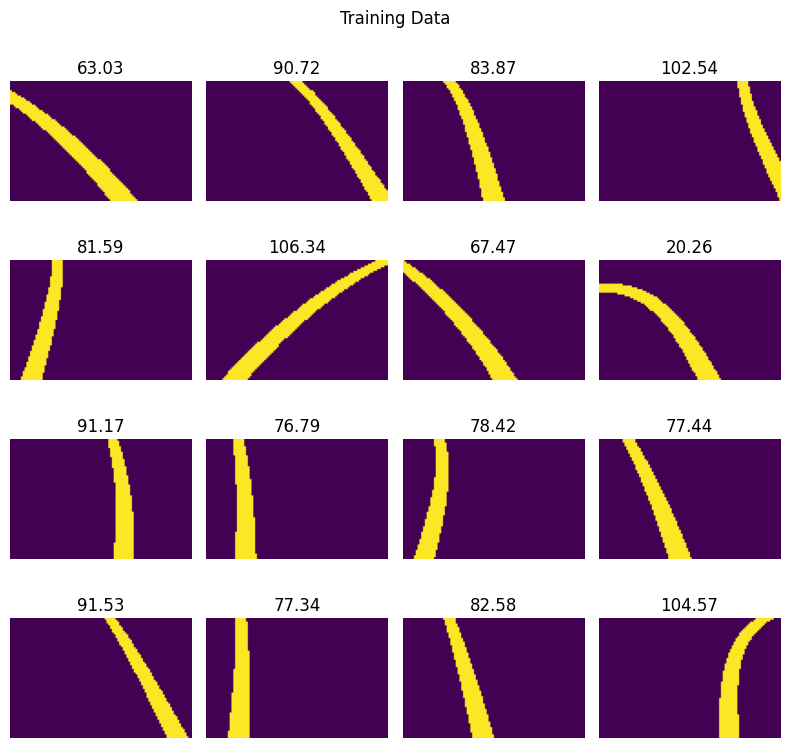

In [ ]:
# output the first 16 images and steering angles from the dataset
fig, axs = plt.subplots(4, 4, figsize=(8, 8))
# add title to the figure
fig.suptitle('Training Data')
fig.tight_layout()

imgs, steer = next(iter(train_ds)) # get the first batch of images and steering angles

for i in range(16):
    axs[i//4, i%4].axis('off')
    axs[i//4, i%4].imshow(imgs[i])
    axs[i//4, i%4].set_title(round(steer[i].numpy(), 2))
plt.tight_layout()
plt.show()



## Part 5: This is where you will create your model, test and export the .onnx file
Try modifying the layers to try to get the lowest mse score,
This is going to require some trial and error so make sure you spend some time experimenting.

In [ ]:
# Install skl2onnx for ONNX conversion
!pip install skl2onnx

# Import necessary libraries
from sklearn.linear_model import LinearRegression
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from sklearn.metrics import mean_absolute_error, mean_squared_error
import onnx
import numpy as np

# Flatten the train_data and test_data for the linear regression model
train_data_flattened = [img.flatten() for img in train_data]
test_data_flattened = [img.flatten() for img in test_data]

# Train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(train_data_flattened, train_steer)

# Test the model on the test dataset
test_predictions = linear_model.predict(test_data_flattened)

# Evaluate the model performance
mae = mean_absolute_error(test_steer, test_predictions)
mse = mean_squared_error(test_steer, test_predictions)
rmse = np.sqrt(mse)

# Print evaluation results
print("Model Evaluation on Test Data:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Display sample predictions vs actual values
print("\nSample Predictions vs Actual:")
for i in range(5):  # Show 5 examples
    print(f"Predicted: {test_predictions[i]:.2f}, Actual: {test_steer[i]:.2f}")

# Convert the trained model to ONNX format
initial_type = [('float_input', FloatTensorType([None, len(train_data_flattened[0])]))]
onnx_model = convert_sklearn(linear_model, initial_types=initial_type)

# Save the ONNX model to a file
onnx_file_path = "linear_regression_model.onnx"
with open(onnx_file_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"\nLinear Regression model has been saved to {onnx_file_path}")





   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 108.7 MB/s eta 0:00:00
Model Evaluation on Test Data:
Mean Absolute Error (MAE): 26.34
Mean Squared Error (MSE): 1482.53
Root Mean Squared Error (RMSE): 38.50

Sample Predictions vs Actual:
Predicted: 83.53, Actual: 83.13
Predicted: 79.93, Actual: 83.18
Predicted: 82.99, Actual: 83.22
Predicted: 85.74, Actual: 83.28
Predicted: 88.54, Actual: 83.33

Linear Regression model has been saved to linear_regression_model.onnx


# New Section